# Projeto 1: Teoria e Aplicação de Grafos
**Disciplina:** Teoria e Aplicação de Grafos (TAG) - Turma 01 - 2026/1  
**Professor:** Díbio  
**Integrantes:**
* João Gabriel Machado Ferreira - Matrícula: 232003607
* Leandro Coelho Da Silva - Matrícula: 232011396
* Ricardo Martins Fortes - Matrícula: 190044179

In [32]:
import networkx as nx
import pandas as pd
import random
import matplotlib.pyplot as plt
from community import community_louvain

# Definição de semente aleatória para reprodutibilidade dos resultados
random.seed(42)

## 1. Coleta e Amostragem de Dados
Nesta etapa, carregamos o dataset original do Facebook (4039 nós) e realizamos a extração aleatória de exatamente 200 nós. 
Para garantir a unicidade do projeto de cada grupo, as arestas preservadas são apenas aquelas existentes entre os nós sorteados.

In [33]:

# Grafo Completo do Facebook com todos os 4039 nós
Grafo_Full = nx.read_edgelist("data/facebook_combined.txt", create_using=nx.Graph())

# Faz a extração de 200 nós aleatórios do grafo completo
all_nodes = list(Grafo_Full.nodes())
sampled_nodes = random.sample(all_nodes, 200)

# Criar um subgrafo com os nós amostrados e todas as arestas originais entre eles
G = Grafo_Full.subgraph(sampled_nodes).copy()

print(f"Grau de amostragem: {G.number_of_nodes()} nós e {G.number_of_edges()} arestas")

# Teste de aleatoriedade (verificar se os nós mudam sem seed ou se mantêm com seed)
print(f"Amostra de nós: {list(G.nodes())[:5]}")

Grau de amostragem: 200 nós e 210 arestas
Amostra de nós: ['187', '2433', '2795', '1025', '1590']


## 2. Extração de Métricas
Calculamos as quatro medidas de centralidade exigidas pelo roteiro para identificar os nós mais influentes e importantes para o fluxo de informação:
* **Grau:** Quantidade de conexões diretas.
* **Intermediação:** Potencial de controle de fluxo (pontes entre grupos).
* **Proximidade:** Facilidade de alcançar todos os outros nós.
* **Autovetor:** Influência baseada na qualidade das conexões (estar ligado a quem é influente).

In [34]:
# Dicionários para armazenar as métricas

metricas = {
    "Grau": nx.degree_centrality(G),
    "Intermediação": nx.betweenness_centrality(G),
    "Proximidade": nx.closeness_centrality(G),
    "Autovetor": nx.eigenvector_centrality(G, max_iter=1000),
}


# Converter para Dataframe para facilitar a análise no mini-relatório

df_metricas = pd.DataFrame(metricas)

print("Top 5 nós por Grau de Centralidade:")
print(df_metricas.sort_values(by="Grau", ascending=False).head())



Top 5 nós por Grau de Centralidade:
          Grau  Intermediação  Proximidade  Autovetor
1447  0.055276       0.001565     0.067002   0.348484
1598  0.050251       0.001159     0.064840   0.351062
1610  0.045226       0.000957     0.060911   0.335305
1467  0.040201       0.001380     0.059119   0.244608
3078  0.040201       0.000552     0.040536   0.000270


## 3. Mapeamento de Comunidades
Utilizamos o algoritmo de Louvain para detectar subgrupos ou comunidades dentro da rede amostrada, permitindo visualizar como os usuários se agrupam.

In [35]:
# Detecção de comunidade usando o algoritmo de Louvain

particao = community_louvain.best_partition(G)
nx.set_node_attributes(G, particao, "comunidade")
print("\nNúmero de comunidades detectadas:", len(set(particao.values())))



Número de comunidades detectadas: 94


## 4. Visualização
Geramos uma visualização preliminar no notebook e exportamos o arquivo `.gexf` para tratamento avançado no Gephi, onde serão gerados os mapas de cores e rótulos para o relatório final.

In [36]:
# Exportação para o Gephi
nx.set_node_attributes(G, metricas["Grau"], "Grau")
nx.set_node_attributes(G, metricas["Intermediação"], "Intermediacao")
nx.set_node_attributes(G, metricas["Proximidade"], "Proximidade")
nx.set_node_attributes(G, metricas["Autovetor"], "Autovetor")

nx.write_gexf(G, "grafo_amostrado_200.gexf") # Exporta o grafo para um arquivo GEXF, que pode ser importado no Gephi

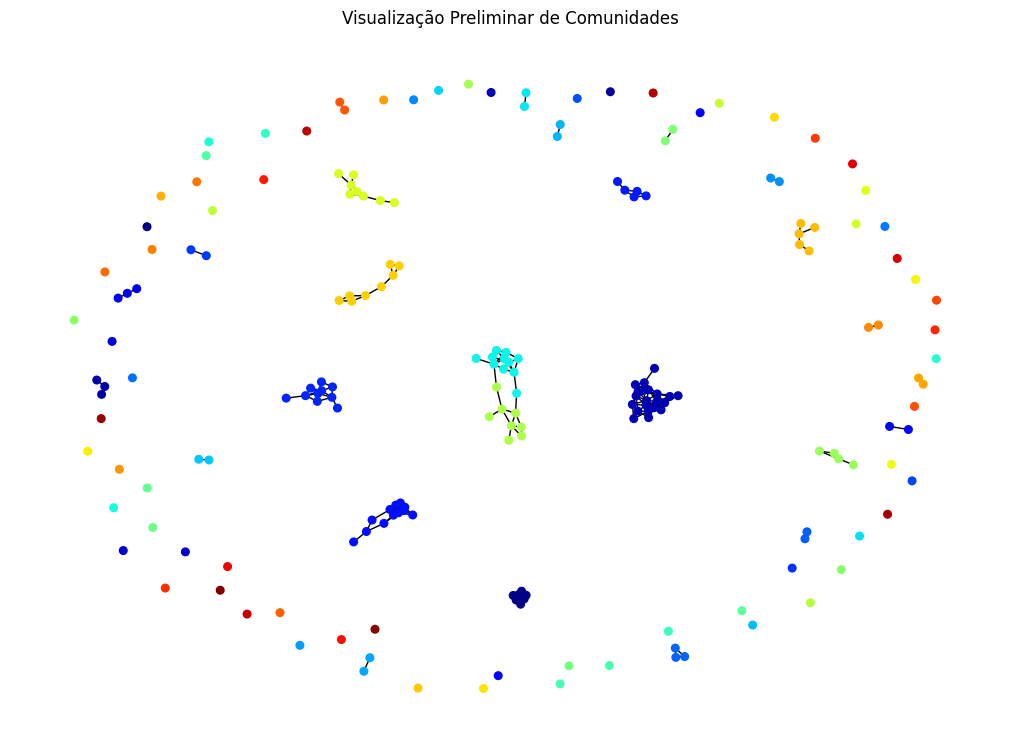

In [37]:

# Verificação visual -> Plot Rápido
plt.figure(figsize=(10, 7))
nx.draw(G, node_size=30, node_color=list(particao.values()), cmap=plt.cm.jet)
plt.title("Visualização Preliminar de Comunidades")
plt.show()